In [10]:
import numpy as np 
import matplotlib.pyplot as plt
import matplotlib.tri as tri
from distmesh import * 
import scipy.sparse as sp
from scipy.sparse.linalg import spsolve

In [5]:
#Mesh generation via dist mesh
def mesh_gen():
    h0 = 0.04

    pfix = np.array([  
        [1, 1], [1, -1], [-1, -1], [-1, 1]
    ])
    f = lambda p: drectangle(p, -1, 1, -1, 1)
    fh = huniform

    bbox = [-1,1,-1,1] # the bounding box

    pts,tri = distmesh2D(f,fh,h0,bbox,pfix)
    return pts, tri

count =  200 displacement =  0.012168586783411093
count =  400 displacement =  0.0034232089969463554
count =  600 displacement =  0.0037272056505444967
count =  800 displacement =  0.003385927624387421
count =  1000 displacement =  0.0026123859523727363
count =  1200 displacement =  0.0023135995093220927


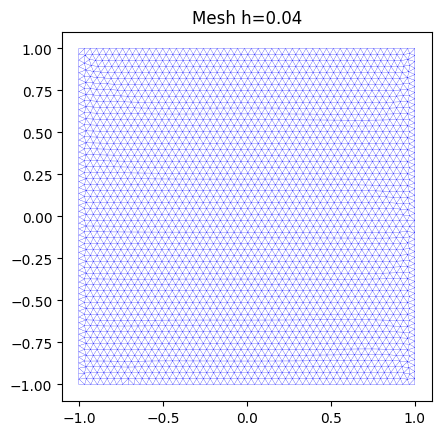

In [6]:
#Creates and plots mesh
pts, tris = mesh_gen() 
plt.triplot(pts[:,0],pts[:,1],tris,linewidth=0.1, color='b')
axes=plt.gca()
axes.set_aspect(1)
plt.title('Mesh h=0.04')
plt.show()

In [7]:
def f(x): return 0

#Local j function
def localj(vertices, U):
    Eps = 1/100
    #Constructs G: [1 1 1; vertices.T] \ [0 0; 1 0; 0 1]
    M = np.vstack([np.ones((1, 3)), vertices.T])
    rhs = np.array([[0, 0], [1, 0], [0, 1]])
    G = np.linalg.solve(M, rhs)
    
    Area = np.linalg.det(M) / 2
    M_const = np.array([[2, 1, 1], [1, 2, 1], [1, 1, 2]]) / 12
    
    # Nonlinear vector construction
    u1, u2, u3 = U[0], U[1], U[2]
    common = 2*u1*u2*u3
    nonlin = np.array([
        4*u1**3 + u2**3 + u3**3 + 3*u1**2*(u2+u3) + 2*u1*(u2**2+u3**2) + u2*u3*(u2+u3) + common,
        4*u2**3 + u1**3 + u3**3 + 3*u2**2*(u1+u3) + 2*u2*(u1**2+u3**2) + u1*u3*(u1+u3) + common,
        4*u3**3 + u2**3 + u1**3 + 3*u3**2*(u2+u1) + 2*u3*(u2**2+u1**2) + u2*u1*(u2+u1) + common
    ])/60
    
    return Area*((Eps * G @ G.T - M_const) @ U + nonlin)

#Local DJ formula
def localdj(vertices, U):
    Eps = 1/100
    M_mat = np.vstack([np.ones((1, 3)), vertices.T])
    G = np.linalg.solve(M_mat, np.array([[0, 0], [1, 0], [0, 1]]))
    Area = np.linalg.det(M_mat)/2
    
    u1, u2, u3 = U[0], U[1], U[2]
    
    #Jacobian of the nonlinear part
    m11 = 12*u1**2 + 2*(u2**2 + u3**2 + u2*u3) + 6*u1*(u2+u3)
    m12 = 3*(u1**2 + u2**2) + u3**2 + 4*u1*u2 + 2*u3*(u1+u2)
    m13 = 3*(u1**2 + u3**2) + u2**2 + 4*u1*u3 + 2*u2*(u1+u3)
    
    m22 = 12*u2**2 + 2*(u1**2 + u3**2 + u1*u3) + 6*u2*(u1+u3)
    m23 = 3*(u2**2 + u3**2) + u1**2 + 4*u2*u3 + 2*u1*(u2+u3)
    
    m33 = 12*u3**2 + 2*(u1**2 + u2**2 + u1*u2) + 6*u3*(u1+u2)
    
    M_nonlin = np.array([
        [m11, m12, m13],
        [m12, m22, m23],
        [m13, m23, m33]
    ]) / 60
    
    M_const = np.array([[2, 1, 1], [1, 2, 1], [1, 1, 2]]) / 12
    return Area * (Eps * G @ G.T - M_const + M_nonlin)

coordinates = pts
elements3 = tris


#I didn't feel like breaking it all up, so just comment/uncomment the right
#boundary condition.
x, y = coordinates[:, 0], coordinates[:, 1]

#0 boundary condition (c)
# unique_dirichlet = np.where(
#     np.isclose(x, -1) | np.isclose(x, 1) | 
#     np.isclose(y, -1) | np.isclose(y, 1)
# )[0]

tol = 1e-6
idx_left   = np.where(np.isclose(x, -1, atol=tol))[0]
idx_right  = np.where(np.isclose(x,  1, atol=tol))[0]
idx_top    = np.where(np.isclose(y,  1, atol=tol))[0]
idx_bottom = np.where(np.isclose(y, -1, atol=tol))[0]

#Combines to get the fixed values
unique_dirichlet = np.unique(np.concatenate([idx_left, idx_right, idx_top, idx_bottom]))


n_coords = coordinates.shape[0]
free_nodes = np.setdiff1d(np.arange(n_coords), unique_dirichlet)

##Same thing with initial values of not wanting to break it all up
U = np.ones(n_coords)

#U[unique_dirichlet] = 0
U[idx_left] = 1
U[idx_right] = 1
U[idx_top] = -1
U[idx_bottom] = -1

#Newton's method
for i in range(50):
    A = sp.lil_matrix((n_coords, n_coords))
    b = np.zeros(n_coords)
    
    #Assembly process
    for j in range(elements3.shape[0]):
        idx = elements3[j, :]
        vertices = coordinates[idx, :]
        
       
        A[np.ix_(idx, idx)] += localdj(vertices, U[idx])
        b[idx] += localj(vertices, U[idx])
        
        #Forcing volume
        det_mat = np.vstack([np.ones(3), vertices.T])
        vol_force = np.linalg.det(det_mat) * f(np.mean(vertices, axis=0)) / 6
        b[idx] += vol_force

    #Newton step
    W = np.zeros(n_coords)
    A_free = A[np.ix_(free_nodes, free_nodes)].tocsr()
    b_free = b[free_nodes]
    
    W[free_nodes] = spsolve(A_free, b_free)
    U -= W
    
    norm_W = np.linalg.norm(W)
    print(f"Iteration {i+1}: Norm = {norm_W:.4e}")
    if norm_W < 1e-10:
        break


Iteration 1: Norm = 1.5864e+01
Iteration 2: Norm = 1.0615e+01
Iteration 3: Norm = 6.6684e+00
Iteration 4: Norm = 4.1350e+00
Iteration 5: Norm = 2.2783e+00
Iteration 6: Norm = 8.5711e-01
Iteration 7: Norm = 1.3379e-01
Iteration 8: Norm = 3.3280e-03
Iteration 9: Norm = 2.1106e-06
Iteration 10: Norm = 8.4587e-13


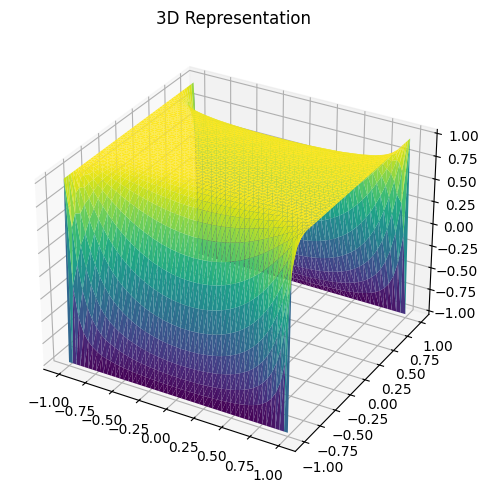

In [11]:
#Plots the result
def show(elements3, coordinates, U):
    x = coordinates[:, 0]
    y = coordinates[:, 1]
    
    tris = tri.Triangulation(x, y, elements3)
    
    fig = plt.figure(figsize=(12, 5))
    
    ax2 = fig.add_subplot(1, 2, 2, projection='3d')
    tps = ax2.plot_trisurf(tris, U, cmap='viridis', edgecolor='none')
    ax2.set_title('3D Representation')
    
    plt.tight_layout()
    plt.show()

#Just call it here
show(elements3, coordinates, U)